In [1]:
import pandas as pd

# dataset.csv ko load karo
df = pd.read_csv("dataset.csv")

# Pehli 5 rows dekho - check karo sahi load hua ya nahi
print("Total rows:", len(df))
df.head()

Total rows: 50


,description,silhouette,fabric,neckline,sleeve,length,embellishment,color,category
0,Floor length chiffon bridesmaid dress with ple...,A-line,chiffon,V neckline,sleeveless,Floor length,none,"sage, dusty blue",bridesmaid dress
1,Sparkly sequin fitted prom gown featuring a de...,Sheath,sequin,illusion neckline,sleeveless,Floor length,sequin embellishment,none,prom gown
2,Off shoulder satin ball gown with corset bodic...,Ball gown,satin,off shoulder,sleeveless,Floor length,none,royal navy,evening gown
3,Lace mermaid wedding dress with long sleeves a...,Mermaid,lace,none,long sleeves,Floor length,none,ivory,wedding dress
4,Short cocktail dress with feather trim and bea...,Sheath,none,none,sleeveless,Short,"feather trim, beaded waist detail",none,cocktail dress


In [2]:
VOCAB = {
    "silhouette": ["a-line", "ball gown", "mermaid", "sheath", "empire", "fit and flare", "trumpet"],
    "fabric": ["chiffon", "satin", "lace", "tulle", "velvet", "sequin", "jersey", "silk", "organza", "crepe"],
    "neckline": ["v neckline", "sweetheart neckline", "off shoulder", "square neckline",
                 "illusion neckline", "halter neckline", "one shoulder", "strapless", "boat neckline"],
    "sleeve": ["long sleeves", "cap sleeves", "puff sleeves", "sleeveless", "three quarter sleeves", "bell sleeves"],
    "length": ["floor length", "short", "tea length", "knee length", "ankle length"],
    "embellishment": ["beaded", "sequin embellishment", "embroidery", "feather trim", "lace applique", "crystal detailing"],
    "color": ["sage", "dusty blue", "royal navy", "ivory", "blush pink", "black", "burgundy", "emerald", "gold", "silver"],
    "category": ["bridesmaid dress", "prom gown", "wedding dress", "cocktail dress", "evening gown", "formal dress"],
}

# check karo kitne attribute types hain
print("Attributes:", list(VOCAB.keys()))

Attributes: ['silhouette', 'fabric', 'neckline', 'sleeve', 'length', 'embellishment', 'color', 'category']


In [3]:
def extract_attributes(description):
    text = description.lower()
    final_result = {}
    
    for attr in VOCAB:
        words_list = VOCAB[attr]
        matched = []
        
        for w in words_list:
            if w in text:
                matched.append(w)
        
        if len(matched) > 0:
            final_result[attr] = ", ".join(matched)
        else:
            final_result[attr] = "none"
    
    return final_result


# test
test_description = "Floor length chiffon bridesmaid dress with pleated bodice and V neckline available in sage and dusty blue"
output = extract_attributes(test_description)
print(output)

{'silhouette': 'none', 'fabric': 'chiffon', 'neckline': 'v neckline', 'sleeve': 'none', 'length': 'floor length', 'embellishment': 'none', 'color': 'sage, dusty blue', 'category': 'bridesmaid dress'}


In [4]:
predictions = []

for i in range(len(df)):
    desc = df.iloc[i]["description"]
    result = extract_attributes(desc)
    predictions.append(result)

pred_df = pd.DataFrame(predictions)
pred_df.head()

,silhouette,fabric,neckline,sleeve,length,embellishment,color,category
0,none,chiffon,v neckline,none,floor length,none,"sage, dusty blue",bridesmaid dress
1,none,sequin,illusion neckline,none,none,none,none,prom gown
2,ball gown,satin,off shoulder,none,none,none,royal navy,none
3,mermaid,lace,none,long sleeves,none,none,none,wedding dress
4,none,none,none,none,short,"beaded, feather trim",none,cocktail dress


In [5]:
attributes = ["silhouette", "fabric", "neckline", "sleeve", "length", "embellishment", "color", "category"]

accuracy_scores = {}

for attr in attributes:
    correct = 0
    total = len(df)
    
    for i in range(total):
        actual_val = str(df.iloc[i][attr]).lower().strip()
        pred_val = str(pred_df.iloc[i][attr]).lower().strip()
        
        if actual_val == pred_val:
            correct = correct + 1
    
    acc = correct / total
    accuracy_scores[attr] = round(acc, 2)

print(accuracy_scores)

{'silhouette': 0.88, 'fabric': 0.74, 'neckline': 0.98, 'sleeve': 0.7, 'length': 0.84, 'embellishment': 0.8, 'color': 0.98, 'category': 0.92}


In [6]:
from sklearn.metrics import f1_score, classification_report

f1_scores = {}

for attr in attributes:
    actual_list = df[attr].astype(str).str.lower().str.strip().tolist()
    pred_list = pred_df[attr].astype(str).str.lower().str.strip().tolist()
    
    f1 = f1_score(actual_list, pred_list, average="macro", zero_division=0)
    f1_scores[attr] = round(f1, 2)

print(f1_scores)

# overall average F1 (sabhi attributes ka average)
overall_f1 = sum(f1_scores.values()) / len(f1_scores)
print("Overall F1:", round(overall_f1, 2))

{'silhouette': 0.82, 'fabric': 0.44, 'neckline': 0.89, 'sleeve': 0.71, 'length': 0.77, 'embellishment': 0.45, 'color': 0.99, 'category': 0.81}
Overall F1: 0.73


In [7]:
wrong_examples = []

for i in range(len(df)):
    actual_val = str(df.iloc[i]["fabric"]).lower().strip()
    pred_val = str(pred_df.iloc[i]["fabric"]).lower().strip()
    
    if actual_val != pred_val:
        wrong_examples.append({
            "description": df.iloc[i]["description"],
            "actual": actual_val,
            "predicted": pred_val
        })

for ex in wrong_examples[:10]:
    print(ex)
    print("---")

{'description': 'Strapless sweetheart neckline glitter gown with layered skirt', 'actual': 'sequin', 'predicted': 'none'}
---
{'description': 'Knee length velvet empire wedding dress with V neckline and cap sleeves, featuring sequin embellishment', 'actual': 'velvet', 'predicted': 'velvet, sequin'}
---
{'description': 'Tea length satin a-line bridesmaid dress with one shoulder and long sleeves, featuring lace applique', 'actual': 'satin', 'predicted': 'satin, lace'}
---
{'description': 'Short velvet ball gown cocktail dress with sweetheart neckline and three quarter sleeves, featuring sequin embellishment', 'actual': 'velvet', 'predicted': 'velvet, sequin'}
---
{'description': 'Ankle length organza empire prom gown with illusion neckline and bell sleeves, featuring lace applique in ivory', 'actual': 'organza', 'predicted': 'lace, organza'}
---
{'description': 'Tea length crepe empire bridesmaid dress with square neckline and cap sleeves, featuring lace applique in gold', 'actual': 'cre

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# hum sirf "category" attribute ke liye ek chhota model train kar rahe hain
# (fabric, color etc already rule-based se ho raha hai, ye extra hai)

X = df["description"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=500)
model.fit(X_train_vec, y_train)

train_acc = model.score(X_train_vec, y_train)
test_acc = model.score(X_test_vec, y_test)

print("Train accuracy:", round(train_acc, 2))
print("Test accuracy:", round(test_acc, 2))

Train accuracy: 0.95
Test accuracy: 0.4


In [9]:
print("===== FINAL SUMMARY =====")
print()
print("Rule-based extractor accuracy (per attribute):")
print(accuracy_scores)
print()
print("Rule-based extractor F1 scores (per attribute):")
print(f1_scores)
print("Overall F1:", round(overall_f1, 2))
print()
print("ML model (category classifier):")
print("Train accuracy:", round(train_acc, 2))
print("Test accuracy:", round(test_acc, 2))
print()
print("Observation: ML model overfits on small dataset (50 rows).")
print("Rule-based matching works better here because attribute values")
print("come from a fixed vocabulary, not free-form text.")

===== FINAL SUMMARY =====

Rule-based extractor accuracy (per attribute):
{'silhouette': 0.88, 'fabric': 0.74, 'neckline': 0.98, 'sleeve': 0.7, 'length': 0.84, 'embellishment': 0.8, 'color': 0.98, 'category': 0.92}

Rule-based extractor F1 scores (per attribute):
{'silhouette': 0.82, 'fabric': 0.44, 'neckline': 0.89, 'sleeve': 0.71, 'length': 0.77, 'embellishment': 0.45, 'color': 0.99, 'category': 0.81}
Overall F1: 0.73

ML model (category classifier):
Train accuracy: 0.95
Test accuracy: 0.4

Observation: ML model overfits on small dataset (50 rows).
Rule-based matching works better here because attribute values
come from a fixed vocabulary, not free-form text.


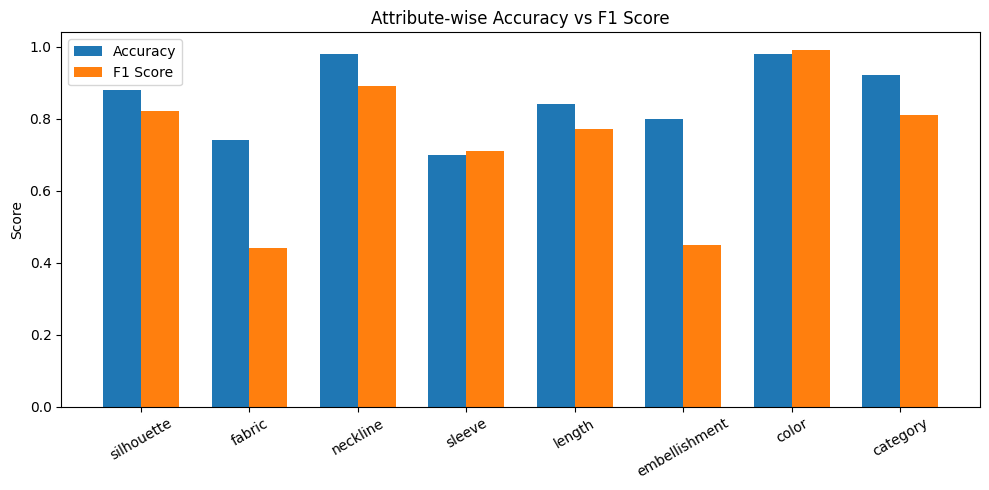

In [10]:
import matplotlib.pyplot as plt

attrs = list(accuracy_scores.keys())
acc_values = list(accuracy_scores.values())
f1_values = [f1_scores[a] for a in attrs]

x = range(len(attrs))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar([i - width/2 for i in x], acc_values, width, label="Accuracy")
plt.bar([i + width/2 for i in x], f1_values, width, label="F1 Score")

plt.xticks(x, attrs, rotation=30)
plt.ylabel("Score")
plt.title("Attribute-wise Accuracy vs F1 Score")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Ab ek bilkul naya description try karte hain jo dataset mein nahi tha
# Ye dikhata hai ki model naye/unseen text pe bhi kaam karta hai

new_description = "Strapless red satin evening gown with beaded bodice and floor length train"

prediction = extract_attributes(new_description)

print("Input:", new_description)
print()
print("Predicted attributes:")
for key, value in prediction.items():
    print(f"  {key}: {value}")

Input: Strapless red satin evening gown with beaded bodice and floor length train

Predicted attributes:
  silhouette: none
  fabric: satin
  neckline: strapless
  sleeve: none
  length: floor length
  embellishment: beaded
  color: none
  category: evening gown
